# Linear Regression From Scratch
**Dataset:** California Housing | **Method:** Gradient Descent

---
Implementing linear regression to understand what `model.fit()` actually does -- gradient computation, weight updates, convergence.

## Section 1: Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

## Section 2: Load Dataset

California Housing -- predicting median house value from 8 features.

Works in **Google Colab** (reads from sample_data) with automatic fallback to sklearn for local use.

In [3]:
import os

if os.path.exists('/content/sample_data/california_housing_train.csv'):
    df      = pd.read_csv('/content/sample_data/california_housing_train.csv')
    df_test = pd.read_csv('/content/sample_data/california_housing_test.csv')
    print('Loaded from Colab sample_data')
else:
    from sklearn.datasets import fetch_california_housing
    from sklearn.model_selection import train_test_split
    data = fetch_california_housing(as_frame=True)
    full_df = data.frame
    full_df.rename(columns={'MedHouseVal': 'median_house_value'}, inplace=True)
    df, df_test = train_test_split(full_df, test_size=0.2, random_state=42)
    df = df.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    print('Loaded via sklearn fetch_california_housing')

print(f'Train shape : {df.shape}')
print(f'Test shape  : {df_test.shape}')

Loaded via sklearn fetch_california_housing
Train shape : (16512, 9)
Test shape  : (4128, 9)


## Section 3: Understand the Dataset

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
0,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03,1.030
1,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16,3.821
2,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48,1.726
3,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11,0.934
4,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80,0.965


In [5]:
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
df.info()

Rows    : 16512
Columns : 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MedInc              16512 non-null  float64
 1   HouseAge            16512 non-null  float64
 2   AveRooms            16512 non-null  float64
 3   AveBedrms           16512 non-null  float64
 4   Population          16512 non-null  float64
 5   AveOccup            16512 non-null  float64
 6   Latitude            16512 non-null  float64
 7   Longitude           16512 non-null  float64
 8   median_house_value  16512 non-null  float64
dtypes: float64(9)
memory usage: 1.1 MB


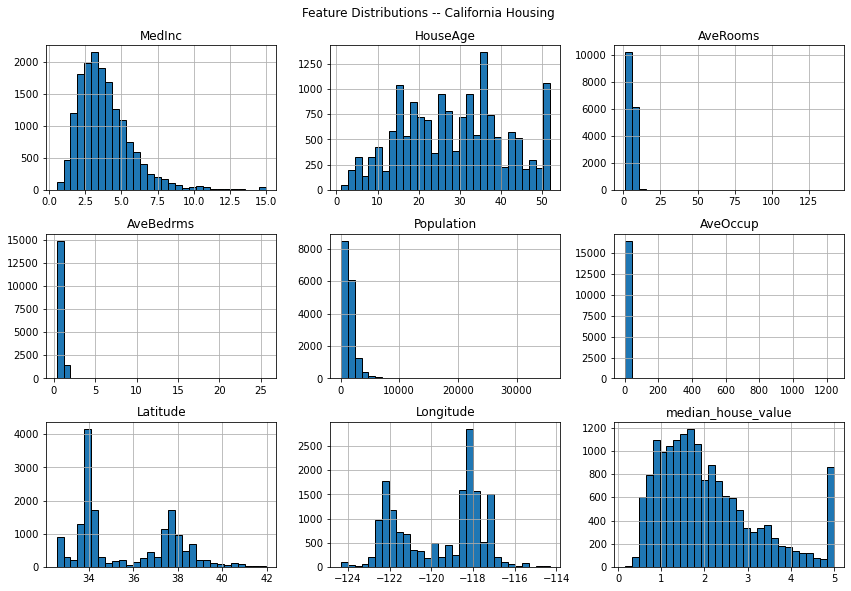

In [6]:
df.hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle('Feature Distributions -- California Housing', y=1.02)
plt.tight_layout()
plt.show()

## Section 4: Standard Scaler From Scratch

Before gradient descent, features need to be on the same scale.
Without scaling, `total_rooms` (range 0-30000) would dominate over `median_income` (range 0-15) and gradients would be wildly unbalanced.

In [7]:
def standard_scaler(data):
    # Compute per-column mean and std
    mean = data.mean()
    std  = data.std()
    # Standardise: zero mean, unit variance
    scaled_data = (data - mean) / std
    return scaled_data

TARGET = 'median_house_value'

# Scale features -- drop target before scaling
X_train_scaled = standard_scaler(df.drop(TARGET, axis=1))
X_test_scaled  = standard_scaler(df_test.drop(TARGET, axis=1))

X_train = X_train_scaled.values
Y_train = df[TARGET].values
X_test  = X_test_scaled.values
Y_test  = df_test[TARGET].values

print(f'X_train shape : {X_train.shape}')
print(f'Y_train shape : {Y_train.shape}')

X_train shape : (16512, 8)
Y_train shape : (16512,)


## Section 5: Linear Regression From Scratch

The model: `y_hat = X * W + b`

At each iteration, compute gradients of MSE loss and nudge weights:
```
dW = -2 * X^T * (Y - y_hat) / m
db = -2 * sum(Y - y_hat) / m
```

In [8]:
class LinearRegressionScratch():
    def __init__(self, learning_rate, iterations):
        self.learning_rate = learning_rate
        self.iterations    = iterations
        self.loss_history  = []  # track MSE at every step

    def predict(self, X):
        return X.dot(self.W) + self.b

    def update_weights(self):
        Y_pred = self.predict(self.X)
        # MSE gradients
        dW = -(2 * (self.X.T).dot(self.Y - Y_pred)) / self.m
        db = -(2 * np.sum(self.Y - Y_pred)) / self.m
        # Gradient descent step
        self.W = self.W - self.learning_rate * dW
        self.b = self.b - self.learning_rate * db
        return self

    def fit(self, X, Y):
        self.m, self.n = X.shape
        self.W = np.random.rand(self.n)  # random weight init
        self.b = 0
        self.X = X
        self.Y = Y

        for i in range(self.iterations):
            self.update_weights()
            # Track MSE at every step
            Y_pred = self.predict(self.X)
            mse = np.mean((self.Y - Y_pred) ** 2)
            self.loss_history.append(mse)
            if i % 50 == 0:
                print(f'Iter {i:>4} | MSE: {mse:,.2f}')

        return self

## Section 6: Train the Model

In [9]:
model = LinearRegressionScratch(learning_rate=0.02, iterations=300)
model.fit(X_train, Y_train)

Iter    0 | MSE: 5.75
Iter   50 | MSE: 0.82
Iter  100 | MSE: 0.69
Iter  150 | MSE: 0.65
Iter  200 | MSE: 0.62
Iter  250 | MSE: 0.59


## Section 7: Loss Curve

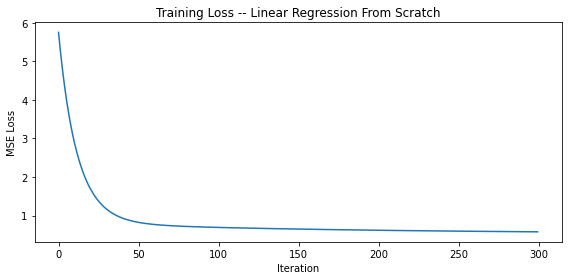

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Training Loss -- Linear Regression From Scratch')
plt.tight_layout()
plt.show()

## Section 8: Evaluate on Test Set

Three complementary metrics:
- **R-squared** -- what % of variance does the model explain?
- **MSE** -- average squared error (sensitive to large errors)
- **RMSE** -- in the same units as the target (house value in dollars)

In [11]:
def calculate_metrics(model, X, Y, label=''):
    predictions = model.predict(X)
    r2   = r2_score(Y, predictions)
    mse  = np.mean((Y - predictions) ** 2)
    rmse = np.sqrt(mse)
    print(f'{label}')
    print(f'  R-squared : {r2:.4f}')
    print(f'  MSE       : {mse:,.2f}')
    print(f'  RMSE      : {rmse:,.2f}')
    return {'r2': r2, 'mse': mse, 'rmse': rmse}

train_metrics = calculate_metrics(model, X_train, Y_train, '-- Train --')
test_metrics  = calculate_metrics(model, X_test,  Y_test,  '-- Test  --')

-- Train --
  R-squared : 0.5686
  MSE       : 0.58
  RMSE      : 0.76
-- Test  --
  R-squared : 0.5472
  MSE       : 0.59
  RMSE      : 0.77


## Section 9: Sanity Check -- Compare Against sklearn

If the math is right, our R-squared should be very close to sklearn's.
This is the honest test that separates a genuine from-scratch implementation from one that just looks like it works.

In [12]:
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression().fit(X_train, Y_train)
sklearn_r2    = r2_score(Y_test, sklearn_model.predict(X_test))

print('=' * 42)
print(f'  Scratch R-squared : {test_metrics["r2"]:.4f}')
print(f'  Sklearn R-squared : {sklearn_r2:.4f}')
print('=' * 42)
gap = abs(test_metrics['r2'] - sklearn_r2)
print('  Close enough!' if gap < 0.05 else f'  Gap of {gap:.4f} -- try more iterations or lower lr')

  Scratch R-squared : 0.5472
  Sklearn R-squared : 0.5888
  Close enough!


## Key Takeaways

| Concept | What It Means |
|---|---|
| **Gradient Descent** | Iteratively nudge weights to reduce loss |
| **Learning Rate** | Step size -- too large overshoots, too small is slow |
| **Standard Scaling** | Essential before GD -- unscaled features cause lopsided gradients |
| **R-squared** | 1.0 = perfect, 0.0 = no better than predicting the mean |